## Linear Regression
Importatn Points:
- Linear Regression with one variable (single feature x).
- Univariate Linear Regression
- linear funcion or linear equation: $$ f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

## Tools
- **Pandas/Numpy:** For data handling and manipulation
- **Matplotlib:** For data visualization (graphs and plots)
- **Scikit-learn (Sklearn):** Used for implementing the linear regression algorithm and for data splitting tools.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# --- STEP 1: LOAD DATA FROM A CSV FILE ---
# If the file is in the same directory, simply use the file name
# If it is located in another directory, specify the full file path
# (e.g., 'C:/Users/Name/Downloads/realistic_housing_data.csv')
df = pd.read_csv('realistic_housing_data.csv')

In [ ]:
# --- STEP 2: SPLIT DATA INTO FEATURES (X) AND TARGET (y) ---
x = df[['Square_Footage']]    # Independent Variable (Input)
y = df[["Price_in_Lakhs"]]    # Dependent Varibale (Output)

# --- STEP 3: TRAIN/TEST SPLIT ---
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


**Real-Life Example (The Exam Analogy):**

Suppose you are a teacher, and you have a book containing 100 questions.
If you make a student memorize all 100 questions and then give the exact same questions in the exam, the student will score 100/100.
However, this does not tell you whether the student is actually intelligent or has simply memorized the answers.
What is the smarter approach?
You teach the student 80 questions (training) and keep the remaining 20 questions hidden to test them later. This way, you can evaluate the student’s true ability.
Machine learning works in exactly the same way.

`x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)`

Let’s break this into 4 parts:

**A. What are X and y?**
- x: House size (square footage) — input
- y: House price — output

**B. The Four Variables on the Left Side**

This function splits your data into four parts:

- x_train: House sizes used for training (80% of the data)
- x_test: House sizes used for testing (20% of the data)
- y_train: Actual prices of the training houses (80% of the data)
- y_test: Actual prices of the test houses, kept hidden from the model during training (20% of the data)

**C. What does test_size = 0.2 mean?**

It means 20% of the data is reserved for testing.

For example, if your CSV file contains 100 rows (houses):

- 20 houses → testing (exam)
- 80 houses → training

**D. What does random_state = 42 mean?**

When you split data randomly, the selection changes every time you run the code. This leads to different results each time.

The value **42** acts as a seed. It ensures that the data is split in the same way every time you run the code, making your results consistent and reproducible.
(You can use any number instead of 42.)

In [15]:
print(x_train)
print(x_test)

    Square_Footage
55            2861
88            1255
26            1259
42            1362
69            3053
..             ...
60            3745
71            2755
14            3719
92            3567
51            2097

[80 rows x 1 columns]
    Square_Footage
83            1001
53            1400
70            3952
45            3679
44            2067
39            3805
22            2015
80            3577
10            1130
0             3974
18            3191
30            3704
73            3873
33            3358
90            1816
4             1895
76            1929
77            2300
12            2935
31            1274


In [ ]:
# --- STEP 4: MODEL TRAINING ---
model = LinearRegression()
model.fit(x_train, y_train)
# --- STEP 5: PREDICTIONS ---
y_prediction = model.predict(x_test)

In [17]:
print(f"Model ki dhoondi hui Slope (m): {model.coef_.item():.4f}")
print(f"Model ka dhoonda hua Intercept (c): {model.intercept_.item():.4f}")


Model ki dhoondi hui Slope (m): 0.0480
Model ka dhoonda hua Intercept (c): 15.0475


**R2 Score**

R-squared (R²) score simply means: *how well your model explains the real-world data in percentage terms.*

In statistical terms, it is called the **Coefficient of Determination.**

The score is usually between 0 and 1 (you can also think of it as 0% to 100%).

| R² Score | Percentage | Meaning |
|----------|------------|---------|
| 1.0      | 100%       | Perfect Model: The model predicts the exact actual values with zero error. |
| 0.80     | 80%        | Very Good Model: The model correctly captures about 80% of the variation in the data. |
| 0.50     | 50%        | Average Model: The model is partially accurate; about half correct and half incorrect. |
| 0.0      | 0%         | Poor Model: The model performs no better than guessing or using the average (mean). It has learned nothing useful. |

In [ ]:
# --- STEP 6: EVALUATION ---
print("\nActual Prices:", y_test.values)
print("\nPredicted Prices:", y_prediction)
print("\nR2 Score:", r2_score(y_test, y_prediction))


Actual Prices: [[ 46.59]
 [ 91.78]
 [202.3 ]
 [187.64]
 [100.66]
 [212.48]
 [114.88]
 [174.96]
 [ 73.37]
 [209.98]
 [156.46]
 [195.01]
 [199.56]
 [163.66]
 [ 93.06]
 [119.36]
 [ 99.  ]
 [124.92]
 [143.97]
 [ 74.38]]

Predicted Prices: [[ 63.08272347]
 [ 82.22964176]
 [204.69313921]
 [191.59261616]
 [114.23714678]
 [197.63901141]
 [111.74180905]
 [186.69791525]
 [ 69.27308051]
 [205.74885901]
 [168.17483139]
 [192.79229776]
 [200.90214536]
 [176.18870446]
 [102.19234354]
 [105.98333739]
 [107.61490436]
 [125.41817926]
 [155.89009183]
 [ 76.18324651]]

R2 Score: 0.9658937207782986


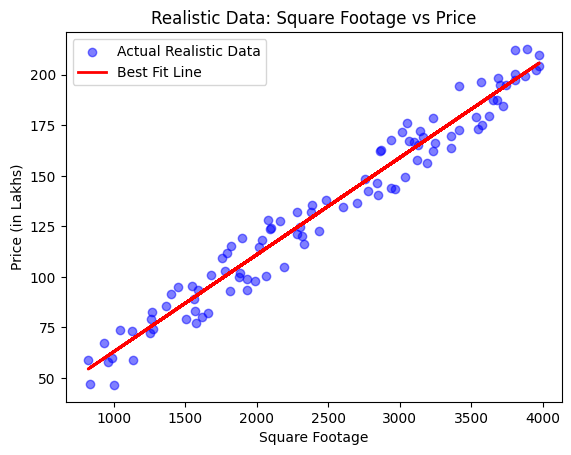

In [ ]:
# --- STEP 7: GRAPH ---
plt.scatter(x, y, color='blue', alpha=0.5, label='Actual Realistic Data')
plt.plot(x, model.predict(x), color='red', linewidth=2, label='Best Fit Line')
plt.xlabel('Square Footage')
plt.ylabel('Price (in Lakhs)')
plt.title('Realistic Data: Square Footage vs Price')
plt.legend()
plt.show()

**NOTE**

For the dataset CSV file, visit the `datasets/realistic_housing_data.csv`.